<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Classifiers_Evaluation_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 3: Using the Caret package and evaluating true error.

In [1]:
pkgs <- c("e1071")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’




In [2]:
library (e1071)

The Caret package provides an environment to do classification


In [3]:
pkgs <- c("caret")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

library(caret)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element


Loading required package: lattice



 When we want repeatable experiments, we can set the seed of the random number generator. Since this is a computer there is nothing actually random - only things that look random. The seed allows us to always get the same sequence of "random" numbers.

This is useful for experiments and class demos. When building models to be used in practice there is never a reason to set the seed.


In [4]:
set.seed(1234)

The most important function in the Caret package is the "train" function that tunes the parameters of a model and returns the model with the "best" parameter values.

In [8]:
pkgs <- c("klaR")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘R.cache’, ‘styler’, ‘classInt’, ‘labelled’, ‘combinat’, ‘questionr’




For nb model in R, klaR needs to install

In [9]:
weather.data = read.csv ("Weather.csv", stringsAsFactors = TRUE)
nb.model = train(weather.data[,1:4], weather.data$Play, method="nb")
weather.predictions = predict(nb.model,weather.data)

In fact, in this case we just get the same NB model as last week. There is really nothing to tune for NB so this is not surprising.

In [10]:
table(weather.data$Play,weather.predictions)
nb.model

      weather.predictions
       No  Yes 
  No     4    1
  Yes    0    9

Naive Bayes 

14 samples
 4 predictor
 2 classes: 'No ', 'Yes ' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 14, 14, 14, 14, 14, 14, ... 
Resampling results across tuning parameters:

  usekernel  Accuracy   Kappa     
  FALSE      0.5278095  0.05975225
   TRUE      0.5278095  0.05975225

Tuning parameter 'fL' was held constant at a value of 0
Tuning
 parameter 'adjust' was held constant at a value of 1
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were fL = 0, usekernel = FALSE and adjust
 = 1.

 An advantage of using the train function instead of directly calling functions from the primary packages is that it returns much more than just the model. For example:


In [11]:
nb.model$results

,usekernel,fL,adjust,Accuracy,Kappa,AccuracySD,KappaSD
,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,FALSE,0,1,0.5278095,0.05975225,0.2027235,0.2259446
2,TRUE,0,1,0.5278095,0.05975225,0.2027235,0.2259446



#### Resampling Estimates of Error ####

*   The train function also allows you to use different evaluation methods to estimate the error (and pick the best parameter values).

*   The default evaluation is a bootstrap; not the 0.632-bootstrap but rather an average of 25 boostrap samples. This estimate will not correct for the fact that this is a very conservative estimate.

The bootstrap estimate of the error is

In [13]:
boot.estimate = max(nb.model$results$Accuracy)
boot.estimate

[1] 0.5278095

We can change it to cross-validation

In [14]:
nb.model = train(weather.data[,1:4], weather.data$Play,
                     method="nb",
                     trControl = trainControl(method="cv"))
cv.estimate = max(nb.model$results$Accuracy)
cv.estimate

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


[1] 0.6

We can also try the 0.632 bootstrap

In [15]:
nb.model = train(weather.data[,1:4], weather.data$Play,
                     method="nb",
                     trControl = trainControl(method="boot632"))
boot632.estimate = max(nb.model$results$Accuracy)
boot632.estimate

[1] 0.6877034

We can compare the three estimates:

In [16]:
boot.estimate
cv.estimate
boot632.estimate

[1] 0.5278095

[1] 0.6

[1] 0.6877034

The model hasn't changed and all of these estimates are trying to estimate the true error of the same model!

Based on theory, All of the estimators, estimate the true accuracy much below the training accuracy. (since bootstrap and cv tends to be pessimistic)

To three estimation methods may have different biases (but they are all biased estimates of the true error), and they also have variance.

Right now we don't know anything about the variance, so let's try to repeat the process a couple of times to see if the three estimators give similar or very different results.

 Let's first store our first resutls in a new data frame

In [17]:
nb.error.estimates = data.frame(
  boot = boot.estimate,
  cv = cv.estimate,
  boot632 = boot632.estimate
)



Now we run train with the three estimators again

In [18]:
nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot"))
boot.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="cv"))
cv.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot632"))
boot632.estimate = max(nb.model$results$Accuracy)


Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


Add the results to our data frame using the "row bind" or rbind() function

In [19]:
nb.error.estimates = rbind(nb.error.estimates,
                           c(boot.estimate,cv.estimate,boot632.estimate))


A third time

In [20]:

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot"))
boot.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="cv"))
cv.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot632"))
boot632.estimate = max(nb.model$results$Accuracy)

nb.error.estimates = rbind(nb.error.estimates,c(boot.estimate,cv.estimate,boot632.estimate))

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


 A fourth time

In [21]:

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot"))
boot.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="cv"))
cv.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot632"))
boot632.estimate = max(nb.model$results$Accuracy)

nb.error.estimates = rbind(nb.error.estimates,c(boot.estimate,cv.estimate,boot632.estimate))

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


Finally, a fifth time

In [22]:
nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot"))
boot.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="cv"))
cv.estimate = max(nb.model$results$Accuracy)

nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="boot632"))
boot632.estimate = max(nb.model$results$Accuracy)

nb.error.estimates = rbind(nb.error.estimates,c(boot.estimate,cv.estimate,boot632.estimate))

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


 Let's look at the results

In [23]:
nb.error.estimates

boot,cv,boot632
<dbl>,<dbl>,<dbl>
0.5278095,0.6000000,0.6877034
0.5953333,0.6000000,0.7119648
0.5612381,0.8500000,0.7122357
0.5340000,0.6500000,0.7408617
0.6604603,0.6111111,0.7796920


---

We run the same nb model 15 times, we get different accuracies/results for true errors

---

We get a wide range of estimates for all three estimators. Thus, we can conclude that all of the error estimates have high variance. We can look at the average and variance

In [24]:
mean(nb.error.estimates$boot)
mean(nb.error.estimates$cv)
mean(nb.error.estimates$boot632)

sqrt(var(nb.error.estimates$boot))
sqrt(var(nb.error.estimates$cv))
sqrt(var(nb.error.estimates$boot632))

[1] 0.5757683

[1] 0.6622222

[1] 0.7264915

[1] 0.05433988

[1] 0.1069643

[1] 0.03519789

It is not surprising that we get high variance for all three estimators when training on such a tiny data set.

My rule of thumb from the lecture notes is that for very small data the 0.632-bootstrap is recommended, and here it does indeed give an estimate that is inbetween the two others (maybe least biased?), and has the lowest estimated variance. But maybe I just got lucky! Since we don't know the true error we cannot say which of the estimators has the least bias (we can never know this), but we can estimate the variance and at least here the 0.632-bootstrap has the least variance (but we would like more than 5 data points to estimate the variance).



#### Independent Test Data ####

*   An alternative to the three sampling estimates above is to use an independent test data. The upside to here is that we'll get an unbiased estimate of the error. The downsides are ...

*   We'll again do five replications, but this time we'll be a little more clever in our programming using a for-loop.

Note: for-loops are hopefully familiar to all of you, and it does the job here, but for-loops in R a VERY slow. The preferred R method for doing repeat calculations is to use apply functions.

In [25]:
set.seed(1234)

independent.test = NULL
for(i in 1:5){
  test = createDataPartition(weather.data$Play, p = 0.33, list=FALSE)
  test.data = weather.data[test,]
  train.data = weather.data[-test,]
  nb.model = naiveBayes(Play~.,data=train.data)
  CM = table(predict(nb.model,test.data),test.data$Play)
  independent.test[i] = (CM[1,1]+CM[2,2])/sum(CM)
}
independent.test
mean(independent.test)
sqrt(var(independent.test))

[1] 0.4 0.8 0.6 0.8 0.6

[1] 0.64

[1] 0.167332

---

test = createDataPartition(weather.data$Play, p = 0.33, list=FALSE)
  *   Create a random split of weather.data.
  *   It divides the data into a test set (33% of the data) and training set (the remaining 67%)
  *   List = FALSE: ensures the output is an integer vector of row indices

independent.test[i] = (CM[1,1]+CM[2,2])/sum(CM)
  *   Calculates the accuracy from the confusion matrix

---

These estimates are all unbiased estimates, but this time it is for five different models (trained on a random 2/3 of the data).

Yes, this is the only way to get an unbiased estimate, but ...

The downsides are that: a) We only get to train on 2/3 of the data, which is a serious limitation when the data is small. b) This estimate has much higher variance than the resampling methods. Thus, even though the bias is zero, the high variance makes this a poor error estimate.

 Using an independent test data should be your go-to option IF you have "enough" data; otherwise, you use a resampling estimate. The tricky part is determine when you have "enough" data.


#### Caret - Using Other Classification Methods ####

*   To do this for other classification methods we can simply change the "method" in the train function, e.g.,

In [26]:
tree.model = train(weather.data[,1:4], weather.data$Play,
                 method="rpart",
                 trControl = trainControl(method="boot632"))
tree.model

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


CART 

14 samples
 4 predictor
 2 classes: 'No ', 'Yes ' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 14, 14, 14, 14, 14, 14, ... 
Resampling results:

  Accuracy   Kappa
  0.5745881  0    

Tuning parameter 'cp' was held constant at a value of 0

There is a default search grid for every built-in model using train

We can also change the search grid.

In [27]:
tree.model = train(weather.data[,1:4], weather.data$Play,
                   method="rpart",
                   tuneGrid = expand.grid(cp = c(0.01, 0.05, 0.1)),
                   trControl = trainControl(method="boot632"))
tree.model

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


CART 

14 samples
 4 predictor
 2 classes: 'No ', 'Yes ' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 14, 14, 14, 14, 14, 14, ... 
Resampling results across tuning parameters:

  cp    Accuracy   Kappa
  0.01  0.5580326  0    
  0.05  0.5580326  0    
  0.10  0.5580326  0    

Accuracy was used to select the optimal model using the largest value.
The final value used for the model was cp = 0.1.

---

tuneGrid = expand.grid(cp = c(0.01, 0.05, 0.1))
*   This argument is used for hyperparameter tuning.
*   It defines a grid of cp values that caret will test.
*   The train () will build and evaluate decision trees for these cp values to find which one performs best.
---

cp is the complexity parameter that controls pruning, but how did I know that this was a parameter that I could change? Look it up!

http://topepo.github.io/caret/available-models.html

The results are not really interesting. Why?

A less direct control is to specify how may values to try for whatever parameter train() wants to change on its own. This can be done using the tuneLength parameter.

In [28]:
tree.model = train(weather.data[,1:4], weather.data$Play,
                   method="rpart",
                   tuneLength = 10,
                   trControl = trainControl(method="boot632"))
tree.model

CART 

14 samples
 4 predictor
 2 classes: 'No ', 'Yes ' 

No pre-processing
Resampling: Bootstrapped (25 reps) 
Summary of sample sizes: 14, 14, 14, 14, 14, 14, ... 
Resampling results:

  Accuracy   Kappa
  0.5472865  0    

Tuning parameter 'cp' was held constant at a value of 0

---
tuneLength = 10
*   Instead of providing a specific tuneGrid of hyperparameter values, tuneLength tells caret to automatically select and evaluate 10 different values for cp across a reasonable range.
---

There is a lot more parameters to be controlled. Read the documentation

 check out the github site: https://github.com/topepo/caret/

In [29]:
?train

#### Selecting the number of folds in CV ####

*   How does the number of folds influence the variance of the CV estimator?

  Start by looking at Naive Bayes with 2-13 folds

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :

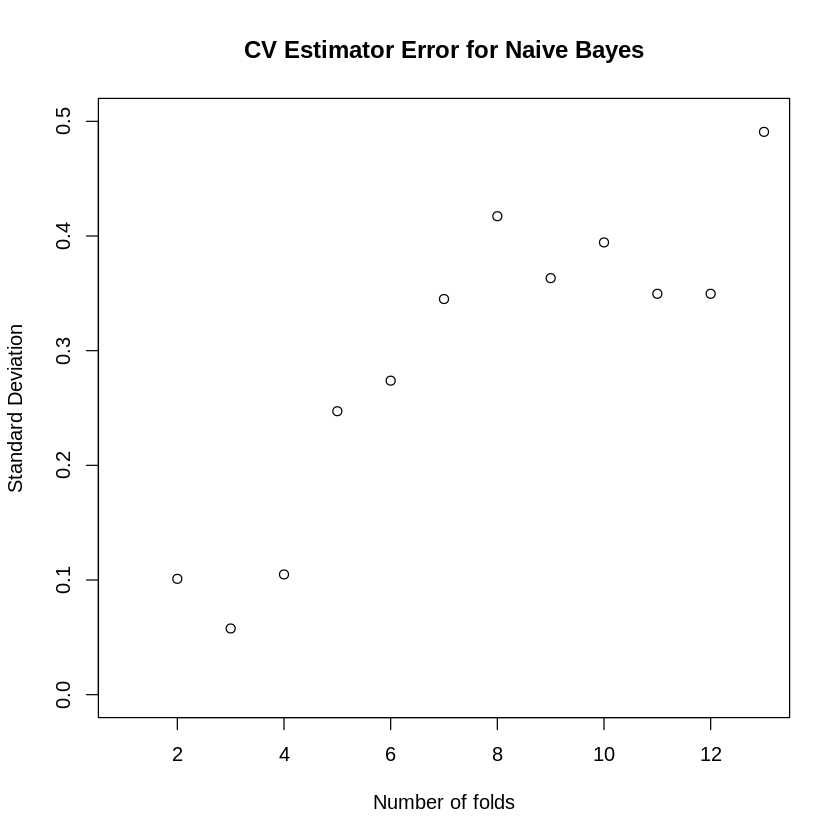

In [30]:
set.seed(3)
cv.estimatesSD = NULL
for(i in 2:13) {
  nb.model = train(weather.data[,1:4], weather.data$Play,
                 method="nb",
                 trControl = trainControl(method="cv", number=i))
  cv.estimatesSD[i] = max(nb.model$results$AccuracySD)
}
plot(cv.estimatesSD,
     ylim = c(0,0.5),
     main="CV Estimator Error for Naive Bayes",
     xlab = "Number of folds",
     ylab = "Standard Deviation")

---

cv.estimatesSD[i] = max(nb.model$results$AccuracySD)
 *   maximum standard deviation of the accuracy

---

The variance of the CV estimator will increase as a function of the number of folds. The maximum number of folds is called Leave-One-Out CV (LOOCV) and this estimator will have the highest variance.

*   When increase fold numbers, each training set becomes smaller. Smaller training sets lead to more variation in the models built across different folds. Also, the training sets in different folds become more similar because they share more data points. These two factors contribute to higher variance. (smaller data in each folds, less representative of the overall population, lead to different accuracy/results)

So why not just use the minimum number of folds?



For some insights into why we see this behavior for CV variance as a function of number of folds:

*   On one hand, as the number of folds increases the size of the training fold decreases, the combined training folds are increasingly positively correlated, and the CV estimator variance increases.

*   On the other hand, as the number of folds increases the size of the combined training folds increases and the variance of the model will tend to decrease (more stable model, less bias and variance model). Thus, when people evaluate the combined variance of the CV and the model, they may observe a different pattern. But this is simply because the reduction in variance for the model is outweighing the increase in variance for the CV estimator.

*   (Note: Next week is all about the model bias and variance and how to reduce it.)

*   One way to observe how the variance of the estimator and the variance of the model can conflate (combine) is by conducting the same experiment for a low variance knn (big k) versus high variance knn (small k)

 Try 2-13 folds and a knn model (k = 9, low variance)

Warning message in knn3Train(train = structure(c(0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, :
“k = 9 exceeds number 7 of patterns”
Warning message in knn3Train(train = structure(c(0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, :
“k = 9 exceeds number 7 of patterns”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.

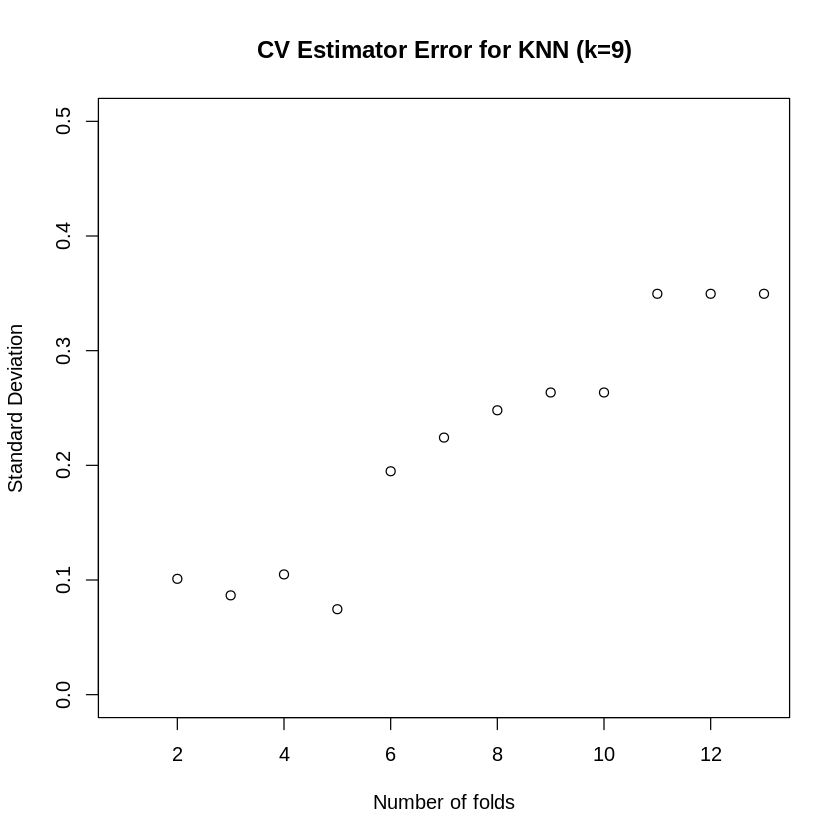

In [31]:
set.seed(3)
cv.estimatesSD = NULL
for(i in 2:13) {
  knn.model = train(Play~., weather.data,
                   method="knn",
                   trControl = trainControl(method="cv", number=i),
                   tuneGrid=expand.grid(k=9))
  cv.estimatesSD[i] = max(knn.model$results$AccuracySD)
}
plot(cv.estimatesSD,
     ylim = c(0,0.5),
     main="CV Estimator Error for KNN (k=9)",
     xlab = "Number of folds",
     ylab = "Standard Deviation")

Try 2-14 folds and a knn model (k = 1, high variance)

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”
Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :

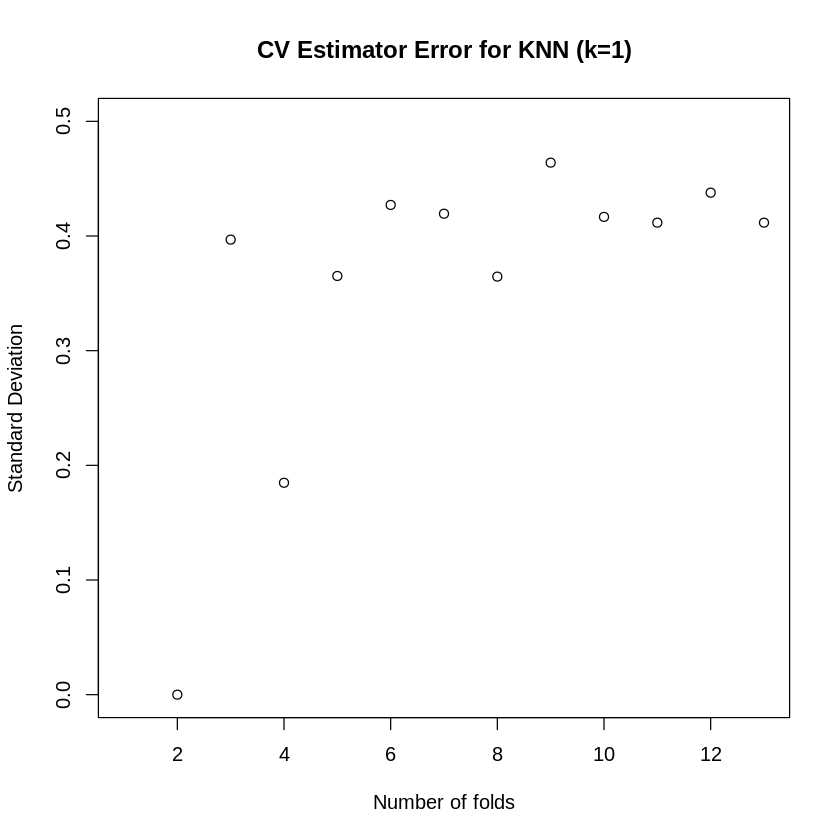

In [32]:
set.seed(3)
cv.estimatesSD = NULL
for(i in 2:13) {
  knn.model = train(Play~., weather.data,
                    method="knn",
                    trControl = trainControl(method="cv", number=i),
                    tuneGrid=expand.grid(k=1))
  cv.estimatesSD[i] = max(knn.model$results$AccuracySD)
}
plot(cv.estimatesSD,
     ylim = c(0,0.5),
     main="CV Estimator Error for KNN (k=1)",
     xlab = "Number of folds",
     ylab = "Standard Deviation")